In [3]:
import os

# IMPORTANT: Replace with your actual Twitch application credentials
os.environ["TWITCH_CLIENT_ID"] = "pgapguj2m5e5mm637jg1sx952kjdzw"
os.environ["TWITCH_CLIENT_SECRET"] = "du7gazte4165jh8rn8w4pao37zpazi"

print("TWITCH_CLIENT_ID and TWITCH_CLIENT_SECRET environment variables set.")

TWITCH_CLIENT_ID and TWITCH_CLIENT_SECRET environment variables set.


In [4]:
import pandas as pd
import os
from pathlib import Path

# Find the latest games CSV file in the 'igdb_csv' directory
outdir = Path("/Users/woodsprocise/Documents/IU Indy - Fall '25/Video Game Project - woods recent/igdb_csv")
if outdir.exists():
	try:
		latest_games_file = sorted(outdir.glob("games_*.csv"), reverse=True)[0]
		print(f"Loading data from: {latest_games_file}")
		df = pd.read_csv(latest_games_file)
		print(df.head())  # show first 5 rows
	except IndexError:
		print("No games CSV file found in 'igdb_csv' directory.")
		print("Please run the data download cell first.")
else:
	print("'igdb_csv' directory not found.")
	print("Please run the data download cell first to create it.")

Loading data from: /Users/woodsprocise/Documents/IU Indy - Fall '25/Video Game Project - woods recent/igdb_csv/games_20251015_1657.csv
   id  aggregated_rating aggregated_rating_count first_release_date   genres  \
0   1          90.000000                     1.0          953596800  5|13|31   
1   2          70.000000                     1.0          912384000    13|31   
2   3          83.000000                     2.0         1085443200  5|13|31   
3   4          63.642857                    14.0         1393286400     5|31   
4   5                NaN                     NaN          914198400       12   

                      name        platforms                    slug  \
0  Thief II: The Metal Age                6  thief-ii-the-metal-age   
1  Thief: The Dark Project                6  thief-the-dark-project   
2    Thief: Deadly Shadows             11|6    thief-deadly-shadows   
3                    Thief  9|48|6|14|12|49                   thief   
4            Baldur's Gate   

In [5]:
# Loading in most recent 'games.csv' file
import pandas as pd
from pathlib import Path

# Adjust timestamp to your generated CSVs
ts = "20251015_1657"  
outdir = Path("/Users/woodsprocise/Documents/IU Indy - Fall '25/Video Game Project - woods recent/igdb_csv")

games = pd.read_csv(outdir / f"games_20251015_1657.csv")

In [6]:
import pandas as pd

# Load games csv
df = pd.read_csv("games_20251015_1657.csv")

# Keep relevant columns only
df = df[["name", "aggregated_rating", "first_release_date"]].copy()

# Drop rows missing key information
df = df.dropna(subset=["aggregated_rating", "first_release_date"])

# Cleaning 'aggregated_rating' and 'first_release_date' data
"""
Cleaning 'aggregated_rating' column by converting to numeric.
Values may also be strings or NaN.
Formatting all ratings to 1 decimal place.
Format strictly to 1 decimal
"""
df["aggregated_rating"] = pd.to_numeric(df["aggregated_rating"], errors="coerce")
df["aggregated_rating"] = df["aggregated_rating"].round(1)
df["aggregated_rating"] = df["aggregated_rating"].map(lambda x: f"{x:.1f}" if pd.notna(x) else "")

"""
Ensuring timestamps are numeric.
Converting timestamp to year.
Dropping bad rows that couldn't convert.
"""
df["first_release_date"] = (
    pd.to_numeric(df["first_release_date"], errors="coerce")
      .astype("Int64")
)

df["release_year"] = pd.to_datetime(
    df["first_release_date"], unit="s", errors="coerce"
).dt.year

df = df.dropna(subset=["release_year"])
df["release_year"] = df["release_year"].astype(int)

# Compute the top-rated game per year
top_games_by_year = (
    df.sort_values("aggregated_rating", ascending=False)
      .groupby("release_year")
      .first()
      .reset_index()
      .sort_values("release_year")
)

print(top_games_by_year)
df.head()

    release_year                                        name  \
0           1969                                Lunar Lander   
1           1970                                        1942   
2           1979                                   Asteroids   
3           1980                                     Berzerk   
4           1981                                   Centipede   
5           1982                                 Ms. Pac-Man   
6           1983                                 The Witness   
7           1984                    Mickey's Space Adventure   
8           1985                           Ghosts 'n Goblins   
9           1986                                   Alter Ego   
10          1987                      International Karate +   
11          1988         Last Ninja 2: Back with a Vengeance   
12          1989                          Disney's DuckTales   
13          1990                                      F-Zero   
14          1991                        

,name,aggregated_rating,first_release_date,release_year
0,Thief II: The Metal Age,90.0,953596800,2000
1,Thief: The Dark Project,70.0,912384000,1998
2,Thief: Deadly Shadows,83.0,1085443200,2004
3,Thief,63.6,1393286400,2014
5,Baldur's Gate II: Shadows of Amn,90.0,969494400,2000


In [16]:
import pandas as pd

# Step 1: Load games csv
df = pd.read_csv("games_20251015_1657.csv")

# Step 2: Keep relevant columns only
df = df[["name", "aggregated_rating", "first_release_date"]].copy()

# Step 3: 'Clean aggregated_rating'
# Convert to numeric, coerce errors to NaN
df["aggregated_rating"] = pd.to_numeric(df["aggregated_rating"], errors="coerce")

# Round to 1 decimal
df["aggregated_rating"] = df["aggregated_rating"].round(1)

# Optional: strictly format as string with 1 decimal
df["aggregated_rating"] = df["aggregated_rating"].map(lambda x: f"{x:.1f}" if pd.notna(x) else "")

# Step 4: Convert release date to year
df["first_release_date"] = (
    pd.to_numeric(df["first_release_date"], errors="coerce")
      .astype("Int64")
)

df["release_year"] = pd.to_datetime(
    df["first_release_date"], unit="s", errors="coerce"
).dt.year

df = df.dropna(subset=["release_year"])
df["release_year"] = df["release_year"].astype(int)

# Step 5: Filter for games released after 1997
df_filtered_1998 = df[df["release_year"] > 1997].reset_index(drop=True)

print(df_filtered_1998)

                             name aggregated_rating  first_release_date  \
0         Thief II: The Metal Age              90.0           953596800   
1         Thief: The Dark Project              70.0           912384000   
2           Thief: Deadly Shadows              83.0          1085443200   
3                           Thief              63.6          1393286400   
4                   Baldur's Gate                             914198400   
...                           ...               ...                 ...   
3991  Spec Ops: Ranger Team Bravo                             907113600   
3992    Spec Ops II: Green Berets                             941328000   
3993     Spec Ops: Stealth Patrol                             932860800   
3994     Spec Ops II: Omega Squad                             972345600   
3995       Spec Ops: Ranger Elite                             979257600   

      release_year  
0             2000  
1             1998  
2             2004  
3             2

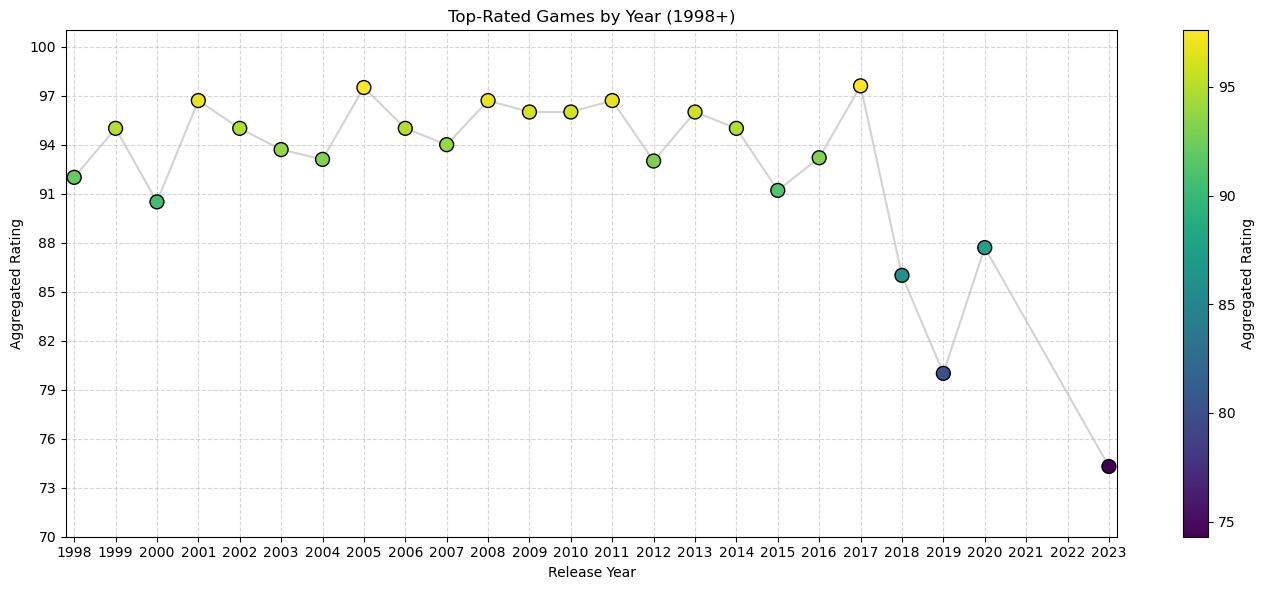

Top Games by Aggregated Rating
    release_year                                        name  \
0           2017     The Legend of Zelda: Breath of the Wild   
1           2005             Metal Gear Solid 3: Subsistence   
2           2008   World of Warcraft: Wrath of the Lich King   
3           2001                                         Ico   
4           2011                              Gears of War 3   
5           2010                              God of War III   
6           2013                                     Ingress   
7           2009        Mario & Luigi: Bowser's Inside Story   
8           1999                                      Driver   
9           2006                           Company of Heroes   
10          2002                             TimeSplitters 2   
11          2014               The Binding of Isaac: Rebirth   
12          2007                           World in Conflict   
13          2003      Star Wars: Knights of the Old Republic   
14       

,release_year,name,aggregated_rating
0,2017,The Legend of Zelda: Breath of the Wild,97.6
1,2005,Metal Gear Solid 3: Subsistence,97.5
2,2008,World of Warcraft: Wrath of the Lich King,96.7
3,2001,Ico,96.7
4,2011,Gears of War 3,96.7
5,2010,God of War III,96.0
6,2013,Ingress,96.0
7,2009,Mario & Luigi: Bowser's Inside Story,96.0
8,1999,Driver,95.0
9,2006,Company of Heroes,95.0


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# --- Plot line with color-coded points ---
plt.figure(figsize=(14,6))

# Line connecting points
plt.plot(top_games_by_year["release_year"], top_games_by_year["aggregated_rating"],
         linestyle="-", color="lightgray", zorder=1)

# Scatter points with color based on rating
sc = plt.scatter(
    top_games_by_year["release_year"],
    top_games_by_year["aggregated_rating"],
    c=top_games_by_year["aggregated_rating"],
    cmap="viridis",
    s=100,  # size of points
    edgecolors="k",
    zorder=2
)

plt.title("Top-Rated Games by Year (1998+)")
plt.xlabel("Release Year")
plt.ylabel("Aggregated Rating")

# Set X-axis increments from 1998 to 2025
x_ticks = np.arange(1998, 2025, 1.0) # increments of 1 year
plt.xticks(x_ticks)

# Set Y-axis increments from 70.0 to 99.9
y_ticks = np.arange(70.0, 101.0, 3.0)  # increments of 3
plt.yticks(y_ticks)

plt.xlim(1997.8, 2023.2)
plt.ylim(70.0, 101.0)

# Grid
plt.grid(True, linestyle="--", alpha=0.5)

# Colorbar as legend for ratings
cbar = plt.colorbar(sc)
cbar.set_label("Aggregated Rating")

plt.tight_layout()
plt.show()

# Key/Table: top games sorted by rating descending
top_games_key = top_games_by_year.sort_values("aggregated_rating", ascending=False)[["release_year", "name", "aggregated_rating"]].reset_index(drop=True)
print("Top Games by Aggregated Rating")
print(top_games_key)
top_games_key.head(30)

In [1]:
"""
Although IGDB data has tracked information and video game trends since the 1950s, aggregated rating
began being tracked in the 1990s, and is a much newer metric. Aggregated ratings are both calculated and
combined scores from numerous individual ratings, that creates a weighted average. For video games, the IGDB
data is collected from individuals who have played these video games who then rate them on a 0-100 scale, with 
a 100 rating being the best. An aggregated rating with a score above 90.0 is an excellent rating as it takes in 
grades from numerous individuals, proving a games widespread popularity. The line plot above highlights the games
that received the highest aggregate rating since 1998, but more importantly provide insights on the trends over the 
last 25 years based on the top overall game each year. What is both surprising and concerning is the recent free fall 
in the highest overall aggregate rated video game in recent years. In fact, the highest overall rated game in 2023,
'Dead Island 2' has by far the lowest top rating over the last 25 years, barely eclipsing 70.0. This trend could be due
to a larger selection of games to play than ever before, resulting in diverse popularity of genres and games among the 
gaming community or perhaps players are more critical than every before because of what video game developers are capable 
of, yet this trend is still difficult to comprehend. With better than ever technology, graphics, gameplay, and developers, 
it would make great sense that the best rated video games ever are the most recent video games. This is not the case, and credit
must be given to the highest rated games of all time (game names.....) coming out in 2005 and 2017, likely with original storylines 
and unique gameplay that has never been created before, leading to their high rating score and widespread popularity.

It is important to note that the quantity of games eligible to receive 'aggregated_ratings' goes down significantly after the year 2020 as newer
games have not received enough reviews to be added to the data files, as games released in 2021, 2022, 2024, and 2025 do not have any aggregated 
ratings yet, and 2023 only as one game with an aggregated rating. Another point to mention is the aggregated ratings are likely a combination of 
user and critic ratings.
"""

"\nAlthough IGDB data has tracked information and video game trends since the 1950s, aggregated rating\nbegan being tracked in the 1990s, and is a much newer metric. Aggregated ratings are both calculated and\ncombined scores from numerous individual ratings, that creates a weighted average. For video games, the IGDB\ndata is collected from individuals who have played these video games who then rate them on a 0-100 scale, with \na 100 rating being the best. An aggregated rating with a score above 90.0 is an excellent rating as it takes in \ngrades from numerous individuals, proving a games widespread popularity. The line plot above highlights the games\nthat received the highest aggregate rating since 1998, but more importantly provide insights on the trends over the \nlast 25 years based on the top overall game each year. What is both surprising and concerning is the recent free fall \nin the highest overall aggregate rated video game in recent years. In fact, the highest overall rate

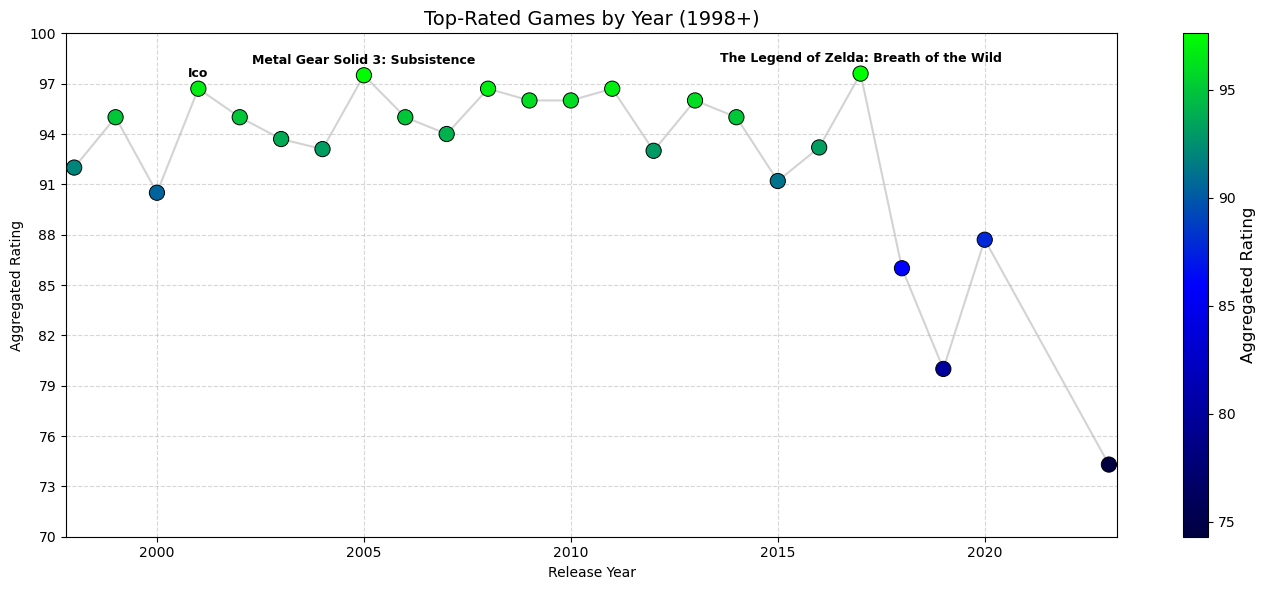

Top Games by Aggregated Rating
    release_year                                        name  \
0           2017     The Legend of Zelda: Breath of the Wild   
1           2005             Metal Gear Solid 3: Subsistence   
2           2008   World of Warcraft: Wrath of the Lich King   
3           2001                                         Ico   
4           2011                              Gears of War 3   
5           2010                              God of War III   
6           2013                                     Ingress   
7           2009        Mario & Luigi: Bowser's Inside Story   
8           1999                                      Driver   
9           2006                           Company of Heroes   
10          2002                             TimeSplitters 2   
11          2014               The Binding of Isaac: Rebirth   
12          2007                           World in Conflict   
13          2003      Star Wars: Knights of the Old Republic   
14       

,release_year,name,aggregated_rating
0,2017,The Legend of Zelda: Breath of the Wild,97.6
1,2005,Metal Gear Solid 3: Subsistence,97.5
2,2008,World of Warcraft: Wrath of the Lich King,96.7
3,2001,Ico,96.7
4,2011,Gears of War 3,96.7
5,2010,God of War III,96.0
6,2013,Ingress,96.0
7,2009,Mario & Luigi: Bowser's Inside Story,96.0
8,1999,Driver,95.0
9,2006,Company of Heroes,95.0


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# Find top-rated game per year
top_games_by_year = (
    df_filtered_1998.sort_values("aggregated_rating", ascending=False)
               .groupby("release_year", as_index=False)
               .first()
)

# Ensure 'aggregated_rating' is numeric for plotting
top_games_by_year["aggregated_rating"] = pd.to_numeric(top_games_by_year["aggregated_rating"], errors="coerce")

# --- Custom green → blue → dark blue colormap ---
colors = ["#000040", "#0000ff", "#00ff00"]  # green → blue → dark blue
green_blue_cmap = LinearSegmentedColormap.from_list("DarkBlueGreen", colors)

# --- Plot ---
plt.figure(figsize=(14,6))

# Line for visual flow
plt.plot(
    top_games_by_year["release_year"],
    top_games_by_year["aggregated_rating"],
    linestyle="-",
    color="lightgray",
    linewidth=1.5,
    zorder=1
)

# Scatter points with the new gradient map
sc = plt.scatter(
    top_games_by_year["release_year"],
    top_games_by_year["aggregated_rating"],
    c=top_games_by_year["aggregated_rating"],
    cmap=green_blue_cmap,
    s=120,
    edgecolors="black",
    linewidth=0.7,
    zorder=2
)

plt.title("Top-Rated Games by Year (1998+)", fontsize=14)
plt.xlabel("Release Year")
plt.ylabel("Aggregated Rating")

# Set X-axis increments from 1998 to 2025
x_ticks = np.arange(2000, 2025, 5.0) # increments of 1 year
plt.xticks(x_ticks)

# Set Y-axis increments from 70.0 to 99.9
y_ticks = np.arange(70.0, 101.0, 3.0)  # increments of 3
plt.yticks(y_ticks)

plt.xlim(1997.8, 2023.2)
plt.ylim(70.0, 100.0)

plt.grid(True, linestyle="--", alpha=0.5)

# Enhanced colorbar
cbar = plt.colorbar(sc)
cbar.set_label("Aggregated Rating", fontsize=12)

# Label only the top 3 highest-rated games
top3 = top_games_by_year.nlargest(3, "aggregated_rating")

for _, row in top3.iterrows():
    plt.text(
        row["release_year"],
        row["aggregated_rating"] + 0.7,  # slight offset above point
        row["name"],
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

# Key/Table sorted by rating
top_games_key = top_games_by_year.sort_values("aggregated_rating", ascending=False)[
    ["release_year", "name", "aggregated_rating"]
].reset_index(drop=True)

print("Top Games by Aggregated Rating")
print(top_games_key)
top_games_key.head(30)

In [203]:
def top_games_by_year(df, year, n=10):
    return (
        df[df["release_year"] == year]
        .sort_values("aggregated_rating", ascending=False)
        .head(n)
        [["name", "aggregated_rating", "release_year"]]
    )

print(top_games_by_year(df_filtered_1998, 2017))

                                         name aggregated_rating  release_year
2964  The Legend of Zelda: Breath of the Wild              97.6          2017
3487                                    Aztez              90.0          2017
3783                                  Cuphead              86.9          2017
3165             Hellblade: Senua's Sacrifice              84.3          2017
3837                                  Gorogoa              82.1          2017
3282                            The Long Dark              82.0          2017
2419                            A Hat in Time              79.6          2017
3859                        Little Nightmares              77.7          2017
2968                                 Get Even              73.8          2017
2967                   Mass Effect: Andromeda              73.2          2017


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

import streamlit as st
import pandas as pd
import time
import plotly.express as px

def display_top_games_by_year(game: dict):
    """
    Display a scatter plot with connected points showing top-rated games by year based on aggregated rating.
    Shows an overall representation of the available data.
    
    MEMORY OPTIMIZED: Uses vectorized operations and avoids unnecessary copying
    """
    games_df = load_games()
    if games_df.empty:
        return
    
    # Clean up to keep only rows with both release_year and aggregated_rating
    df = games_df[games_df["release_year"].notna() & games_df["aggregated_rating"].notna()].copy()
    
    if df.empty or len(df) < 5:
        st.caption("Not enough data to show top games by year.")
        return
    
    # Convert year to integer
    df["release_year"] = df["release_year"].astype(int)
    
    # Filter to reasonable year range (e.g., 2000 onwards) to avoid sparse old data
    df = df[df["release_year"] >= 2000]
    
    if df.empty:
        st.caption("No games found in the data range.")
        return
    
    # Get top 3 games per year by aggregated rating and calculate average
    avg_top_rating_by_year = df.groupby("release_year").apply(
        lambda x: x.nlargest(3, "aggregated_rating")["aggregated_rating"].mean()
    ).reset_index()
    avg_top_rating_by_year.columns = ["Year", "Avg Top 3 Rating"]
    
    # Sort by year for proper line connection
    avg_top_rating_by_year = avg_top_rating_by_year.sort_values("Year")
    
    # Build scatter plot with line connecting points
    fig = px.scatter(
        avg_top_rating_by_year,
        x="Year",
        y="Avg Top 3 Rating",
        labels={"Avg Top 3 Rating": "Average Aggregated Rating (Top 3 Games)"},
        color="Avg Top 3 Rating",
        color_continuous_scale="Viridis",
    )
    
    # Add line connecting the points
    fig.add_scatter(
        x=avg_top_rating_by_year["Year"],
        y=avg_top_rating_by_year["Avg Top 3 Rating"],
        mode="lines",
        line=dict(color="rgba(100, 100, 100, 0.5)", width=2),
        showlegend=False,
    )
    
    fig.update_layout(
        title="Top-Rated Games by Year (Average of Top 3)",
        showlegend=False,
        hovermode="x unified",
    )
    
    st.plotly_chart(fig, use_container_width=True)
